In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Data Understanding

In [ ]:
# carregar os dados
df = pd.read_csv("AB_NYC_2019.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

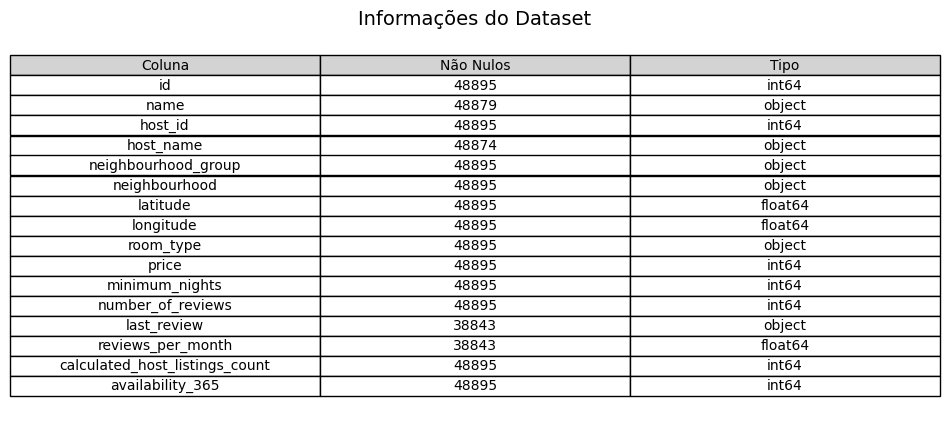

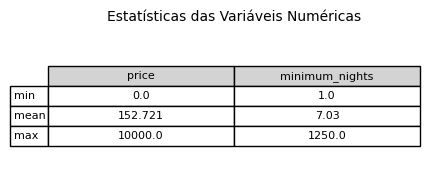

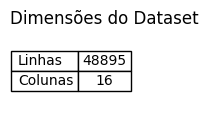

In [4]:
# obter informações gerais do dataset
info_data = str(df.info())
info_data = pd.DataFrame({
    "Coluna": df.columns,
    "Não Nulos": df.count().values,
    "Tipo": df.dtypes.values
})
# tabela de informações
plt.figure(figsize=(10,5))
table = plt.table(cellText=info_data.values, colLabels=info_data.columns, cellLoc='center', loc='center', colColours=["lightgrey"]*3)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.axis('off')
plt.title("Informações do Dataset", fontsize=14)
plt.show()

# estatísticas das variáveis numéricas
cols_of_interest = ['price', 'minimum_nights']
stats_table = df[cols_of_interest].describe().loc[["min", "mean", "max"]]
stats_table.loc["mean"] = stats_table.loc["mean"].round(3)
plt.figure(figsize=(4,2))
table = plt.table(cellText=stats_table.values, colLabels=stats_table.columns, rowLabels=stats_table.index, loc='center', cellLoc='center', colColours=["lightgrey"]*len(stats_table.columns))
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)
plt.axis('off')
plt.title("Estatísticas das Variáveis Numéricas", fontsize=10)
plt.show()

# tabela de dimensões
plt.figure(figsize=(2,1))
dim_df = pd.DataFrame({"Dimensões": df.shape}, index=["Linhas", "Colunas"])
table = plt.table(cellText=dim_df.values, rowLabels=dim_df.index, cellLoc='center', loc='center')
table.auto_set_column_width([0, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.axis('off')
plt.title("Dimensões do Dataset", fontsize=12)
plt.show()

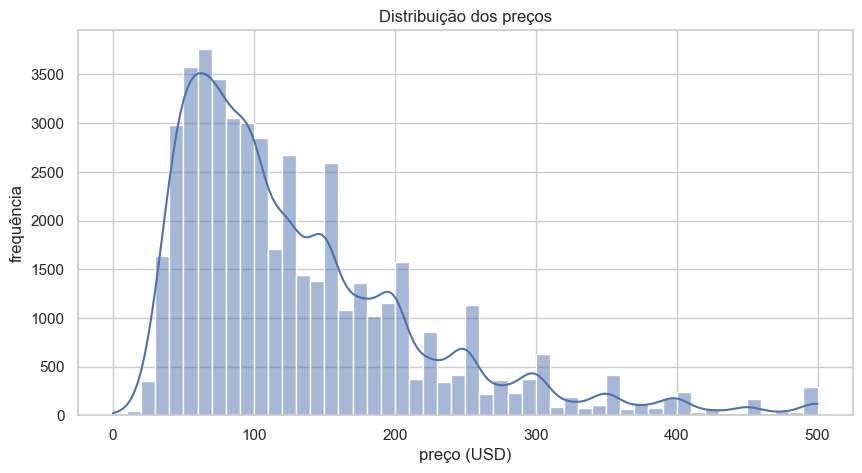

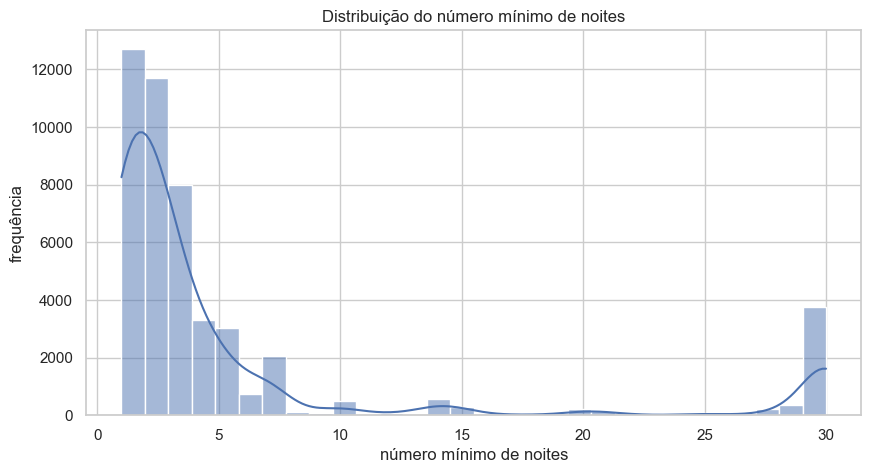

In [5]:
# configuração do estilo dos gráficos
sns.set(style="whitegrid")

# distribuição dos preços até 500
plt.figure(figsize=(10,5))
sns.histplot(df[df["price"] <= 500]["price"], bins=50, kde=True)
plt.title("Distribuição dos preços")
plt.xlabel("preço (USD)")
plt.ylabel("frequência")
plt.show()

# distribuição do número mínimo de noites até 30
plt.figure(figsize=(10,5))
sns.histplot(df[df["minimum_nights"] <= 30]["minimum_nights"], bins=30, kde=True)
plt.title("Distribuição do número mínimo de noites")
plt.xlabel("número mínimo de noites")
plt.ylabel("frequência")
plt.show()

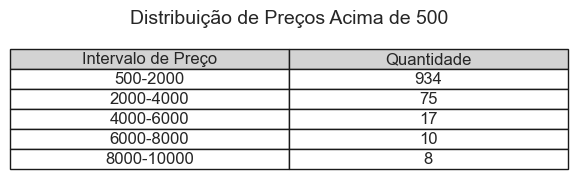

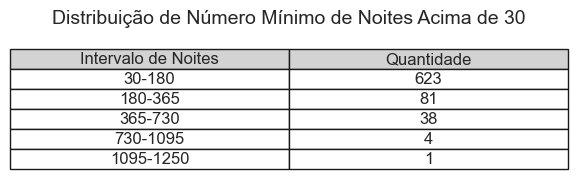

In [7]:
# análise de preços acima de 500
price_bins = [500, 2000, 4000, 6000, 8000, 10000]
price_counts, _ = np.histogram(df[df["price"] > 500]["price"], bins=price_bins)
price_intervals = [f"{int(price_bins[i])}-{int(price_bins[i+1])}" for i in range(len(price_bins)-1)]
# tabela de preços acima de 500
plt.figure(figsize=(6,2))
price_df = pd.DataFrame({"Intervalo de Preço": price_intervals, "Quantidade": price_counts})
table = plt.table(cellText=price_df.values, colLabels=price_df.columns, cellLoc='center', loc='center', colColours=["lightgrey"]*2)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.axis('off')
plt.title("Distribuição de Preços Acima de 500", fontsize=14)
plt.show()

# análise de número mínimo de noites acima de 30
night_bins = [30, 180, 365, 730, 1095, 1250]
night_counts, _ = np.histogram(df[df["minimum_nights"] > 30]["minimum_nights"], bins=night_bins)
night_intervals = [f"{int(night_bins[i])}-{int(night_bins[i+1])}" for i in range(len(night_bins)-1)]
# tabela de número mínimo de noites acima de 30
plt.figure(figsize=(6,2))
night_df = pd.DataFrame({"Intervalo de Noites": night_intervals, "Quantidade": night_counts})
table = plt.table(cellText=night_df.values, colLabels=night_df.columns, cellLoc='center', loc='center', colColours=["lightgrey"]*2)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.axis('off')
plt.title("Distribuição de Número Mínimo de Noites Acima de 30", fontsize=14)
plt.show()

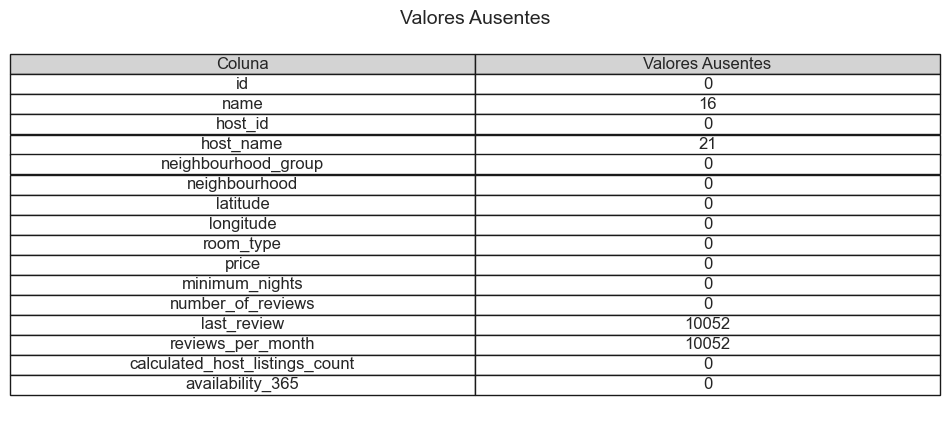


Número de duplicados: 0


In [8]:
# verificar valores ausentes
missing_values = df.isnull().sum()
# tabela de valores ausentes
plt.figure(figsize=(10,5))
missing_df = pd.DataFrame({"Coluna": missing_values.index, "Valores Ausentes": missing_values.values})
table = plt.table(cellText=missing_df.values, colLabels=missing_df.columns, cellLoc='center', loc='center', colColours=["lightgrey"]*2)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.axis('off')
plt.title("Valores Ausentes", fontsize=14)
plt.show()

# verificar valores duplicados
duplicated_values = df.duplicated().sum()
print("\nNúmero de duplicados:", duplicated_values)

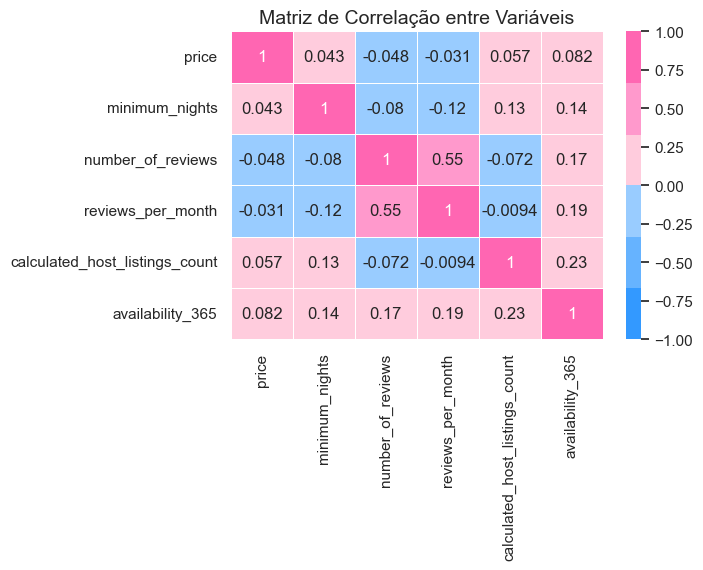

In [ ]:
# matriz de correlação
cols_of_interest = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
corr = df[cols_of_interest].corr()
plt.figure(figsize=(6,4))
pastel_palette = sns.color_palette(["#3399ff", "#66b3ff", "#99ccff", "#ffccdd", "#ff99cc", "#ff66b2"])
sns.heatmap(corr, annot=True, cmap=pastel_palette, linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title("Matriz de Correlação entre Variáveis", fontsize=14)
plt.show()

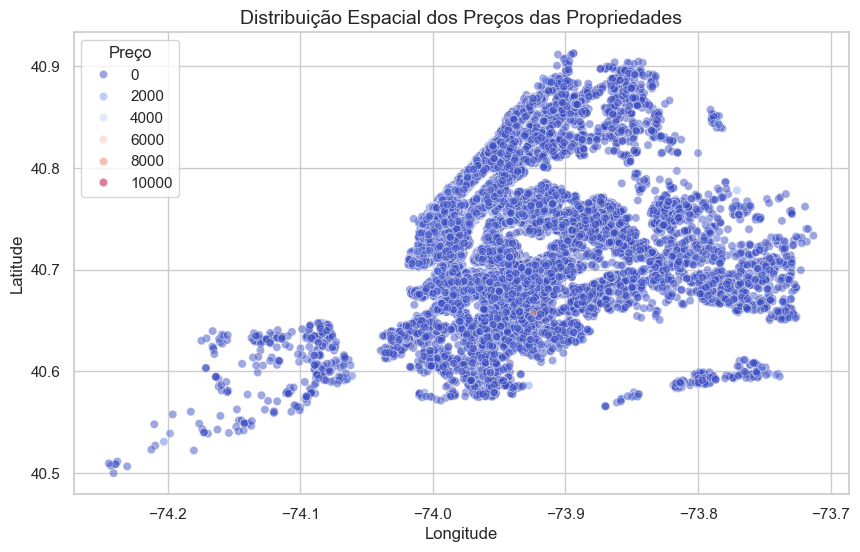

In [10]:
# análise geoespacial - scatter plot de localização dos anúncios
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['longitude'], y=df['latitude'], hue=df['price'], palette='coolwarm', alpha=0.5)
plt.title("Distribuição Espacial dos Preços das Propriedades", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Preço")
plt.show()

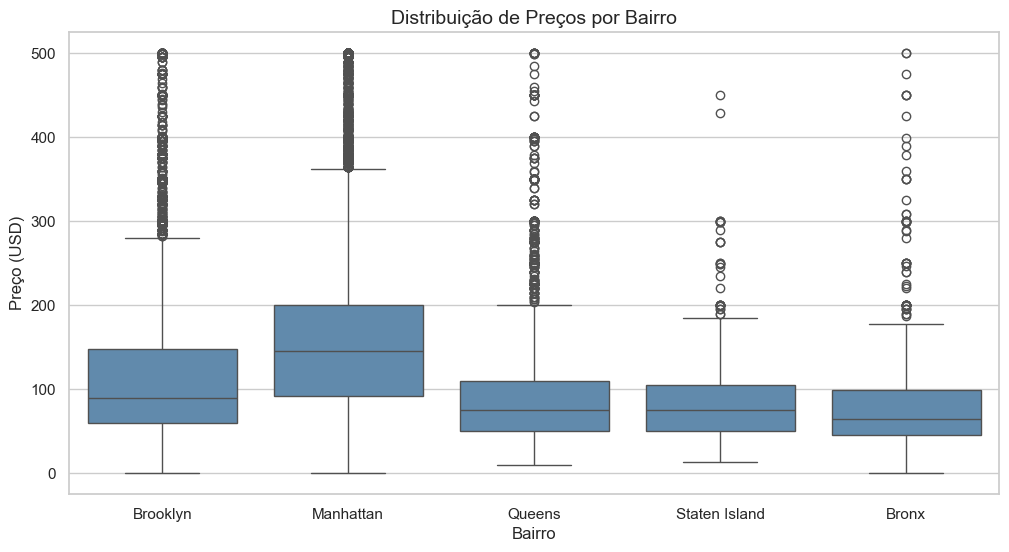

In [11]:
# boxplot de preços por bairro
plt.figure(figsize=(12,6))
sns.boxplot(x="neighbourhood_group", y="price", data=df[df['price'] <= 500], color="#548BB8")
plt.title("Distribuição de Preços por Bairro", fontsize=14)
plt.xlabel("Bairro")
plt.ylabel("Preço (USD)")
plt.show()